<a href="https://colab.research.google.com/github/vucse241fa04b96-lang/CodeAlpha-Tasks/blob/main/Task2_EDA/Task2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 CodeAlpha Internship – Task 2

## Exploratory Data Analysis (EDA)



## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining, cleaning, summarizing, and visualizing a dataset to understand its structure, patterns, relationships, and possible problems.

In this task, the book dataset created during Task 1 – Web Scraping is analyzed using Python.

The analysis focuses on book price, rating, availability, and other variables to identify trends, patterns, anomalies, and relationships in the dataset.

## 1.Loading the Dataset

The dataset created during Task 1 is loaded into Google Colab using Pandas.

In [ ]:
import pandas as pd

df = pd.read_csv("CodeAlpha_Task1_Books_Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2.Libraries Used

The following Python libraries are used for Exploratory Data Analysis:

- Pandas – Data manipulation and analysis
- NumPy – Numerical operations
- Matplotlib – Data visualization
- Seaborn – Statistical visualization
- SciPy – Hypothesis testing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All required libraries imported successfully!")

All required libraries imported successfully!


## 3.Viewing the Dataset

The first few rows of the dataset are displayed to understand the available information.

In [ ]:
df.head()

,Title,Price,Rating,Availability,Product_URL
0,A Light in the Attic,51.77,3,In stock,a-light-in-the-attic_1000/index.html
1,Tipping the Velvet,53.74,1,In stock,tipping-the-velvet_999/index.html
2,Soumission,50.10,1,In stock,soumission_998/index.html
3,Sharp Objects,47.82,4,In stock,sharp-objects_997/index.html
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,sapiens-a-brief-history-of-humankind_996/index...


## 4.Questions Before Analysis

Before analyzing the dataset, the following questions are considered:

1. How many books are present in the dataset?
2. What variables are available?
3. What are the data types of the variables?
4. Are there any missing values?
5. Are there duplicate records?
6. What is the average book price?
7. What are the minimum and maximum prices?
8. Which rating is most common?
9. Are there any unusual book prices?
10. Is there a relationship between book price and rating?
11. What trends and patterns can be identified through visualization?

## 5.Dataset Structure

The shape of the dataset is examined to determine the number of rows and columns.

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 100
Number of Columns: 5


## 6.Column Names

The names of all variables in the dataset are displayed.

In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Title', 'Price', 'Rating', 'Availability', 'Product_URL']


## 7.Data Types

The data types of each variable are examined to determine whether they are numerical or categorical.

In [ ]:
print(df.dtypes)

Title            object
Price           float64
Rating            int64
Availability     object
Product_URL      object
dtype: object


## 8.Dataset Information

The dataset information is examined to understand the columns, number of non-null values, data types, and memory usage.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         100 non-null    object 
 1   Price         100 non-null    float64
 2   Rating        100 non-null    int64  
 3   Availability  100 non-null    object 
 4   Product_URL   100 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


## 9.Missing Values

Missing values can affect data analysis. Therefore, each column is checked for missing values.

In [ ]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Title           0
Price           0
Rating          0
Availability    0
Product_URL     0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Value Percentage:")
print(missing_percentage)

Missing Value Percentage:
Title           0.0
Price           0.0
Rating          0.0
Availability    0.0
Product_URL     0.0
dtype: float64


## 10.Duplicate Records

Duplicate records are checked because they may affect the accuracy of the analysis.

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


## 11.Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables in the dataset.

The analysis includes count, mean, standard deviation, minimum, maximum, and quartiles.

In [ ]:
df.describe()

,Price,Rating
count,100.000000,100.000000
mean,34.560700,2.930000
std,14.638531,1.423149
min,10.160000,1.000000
25%,19.897500,2.000000
50%,34.775000,3.000000
75%,47.967500,4.000000
max,58.110000,5.000000


## 12.Average Book Price

The average price of all books is calculated to understand the typical book price.

In [ ]:
average_price = df["Price"].mean()

print("Average Book Price:", round(average_price, 2))

Average Book Price: 34.56


## 13.Minimum and Maximum Book Price

The minimum and maximum prices are calculated to understand the price range of the books.

In [ ]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())

Minimum Price: 10.16
Maximum Price: 58.11


## 14.Rating Distribution

The number of books for each rating is calculated to identify the most common rating.

In [ ]:
rating_counts = df["Rating"].value_counts().sort_index()

print(rating_counts)

Rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64


In [ ]:
most_common_rating = df["Rating"].mode()[0]

print("Most Common Rating:", most_common_rating)

Most Common Rating: 1


## 15.Identifying Trends and Patterns

The average book price for each rating is calculated to identify whether book prices vary according to ratings.

In [ ]:
average_price_by_rating = (
    df.groupby("Rating")["Price"]
    .mean()
    .round(2)
)

print("Average Price by Rating:")
print(average_price_by_rating)

Average Price by Rating:
Rating
1    35.52
2    35.91
3    36.84
4    33.98
5    30.01
Name: Price, dtype: float64


## 16.Detecting Outliers

An outlier is a value that is unusually high or low compared with the rest of the dataset.

The Interquartile Range (IQR) method is used to identify potential outliers in book prices.

In [ ]:
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Price"] < lower_bound) |
    (df["Price"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

Q1: 19.8975
Q3: 47.9675
IQR: 28.07
Lower Bound: -22.207500000000003
Upper Bound: 90.0725
Number of Outliers: 0


## 17.Outlier Records

The potential outlier records are displayed for further examination.

In [ ]:
outliers[["Title", "Price", "Rating"]]

,Title,Price,Rating


## 18.Boxplot of Book Prices

A boxplot is used to visualize the distribution of book prices and identify potential outliers.

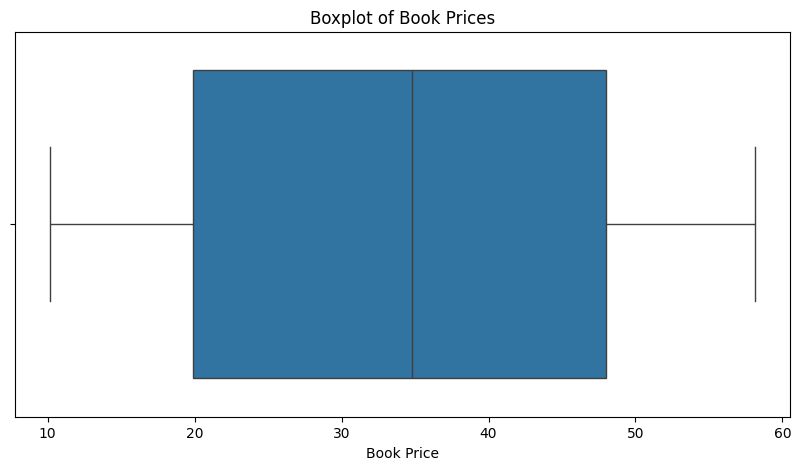

In [ ]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["Price"])

plt.xlabel("Book Price")
plt.title("Boxplot of Book Prices")

plt.show()

## 19.Distribution of Book Prices

A histogram is used to understand how book prices are distributed across the dataset.

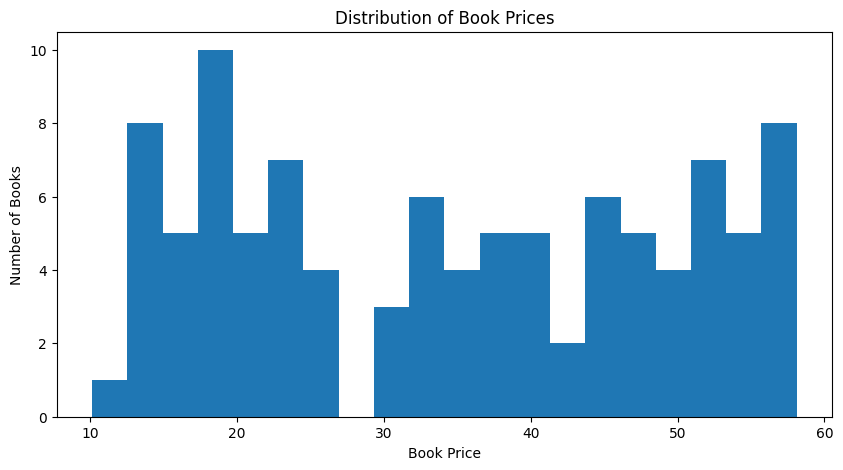

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["Price"], bins=20)

plt.xlabel("Book Price")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

## 20.Distribution of Book Ratings

A bar chart is used to visualize the number of books for each rating.

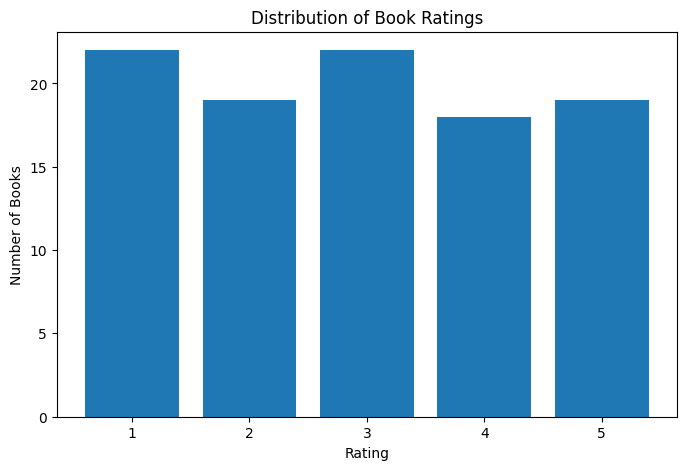

In [ ]:
rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Ratings")

plt.show()

## 21.Relationship Between Price and Rating

A scatter plot is used to examine the relationship between book price and rating.

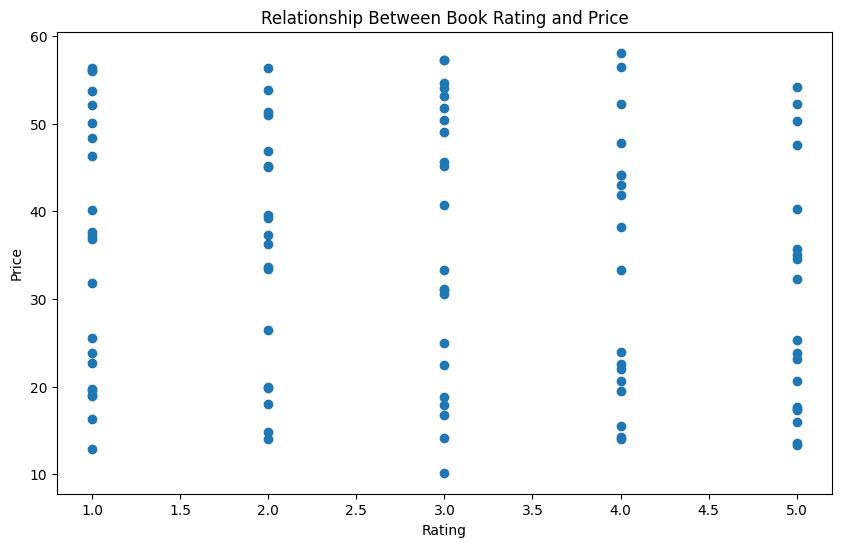

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df["Rating"], df["Price"])

plt.xlabel("Rating")
plt.ylabel("Price")
plt.title("Relationship Between Book Rating and Price")

plt.show()

## 22.Correlation Analysis

Correlation measures the strength and direction of the linear relationship between two numerical variables.

The correlation between book price and rating is calculated.

In [ ]:
correlation = df["Price"].corr(df["Rating"])

print("Correlation between Price and Rating:", round(correlation, 3))

Correlation between Price and Rating: -0.122


## 23.Hypothesis Testing

### Research Question

Do higher-rated books have a different average price compared with lower-rated books?

### Null Hypothesis (H₀)

There is no significant difference in the average prices of lower-rated and higher-rated books.

### Alternative Hypothesis (H₁)

There is a significant difference in the average prices of lower-rated and higher-rated books.

An independent two-sample t-test is used to compare the two groups.

In [ ]:
low_rating = df[df["Rating"] <= 3]["Price"]
high_rating = df[df["Rating"] >= 4]["Price"]

print("Low-rated books:", len(low_rating))
print("High-rated books:", len(high_rating))

Low-rated books: 63
High-rated books: 37


In [ ]:
t_statistic, p_value = stats.ttest_ind(
    low_rating,
    high_rating,
    equal_var=False
)

print("T-statistic:", round(t_statistic, 4))
print("P-value:", round(p_value, 4))

T-statistic: 1.3847
P-value: 0.1701


## 24.Hypothesis Test Interpretation

A significance level of 0.05 is used.

If the p-value is less than 0.05, the null hypothesis is rejected.

If the p-value is greater than or equal to 0.05, the null hypothesis is not rejected.

In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in average prices.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not enough statistical evidence of a significant difference in average prices.")

Fail to reject the null hypothesis.
There is not enough statistical evidence of a significant difference in average prices.


## 25.Average Price Comparison

The average prices of lower-rated and higher-rated books are compared.

In [ ]:
print(
    "Average price of low-rated books:",
    round(low_rating.mean(), 2)
)

print(
    "Average price of high-rated books:",
    round(high_rating.mean(), 2)
)

Average price of low-rated books: 36.1
Average price of high-rated books: 31.94


## 26.Price Comparison Between Rating Groups

A boxplot is used to visually compare the price distributions of lower-rated and higher-rated books.

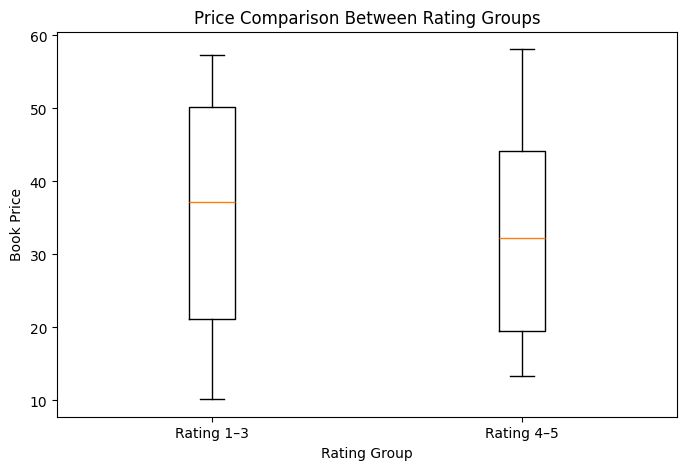

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [low_rating, high_rating],
    tick_labels=["Rating 1–3", "Rating 4–5"]
)

plt.xlabel("Rating Group")
plt.ylabel("Book Price")
plt.title("Price Comparison Between Rating Groups")

plt.show()

## 27.Key Findings

The following findings were obtained from the Exploratory Data Analysis:

1. The structure and variables of the dataset were identified.
2. The data types of all variables were examined.
3. Missing values and duplicate records were checked.
4. Descriptive statistics were calculated for numerical variables.
5. Book price and rating distributions were analyzed.
6. Potential price outliers were identified using the IQR method.
7. The relationship between book price and rating was examined using a scatter plot and correlation.
8. A hypothesis test was performed to compare lower-rated and higher-rated books.
9. Statistical analysis and visualization were used together to understand the dataset.

## 28.Final Dataset Check

The dataset is checked one final time for its dimensions, missing values, and duplicate records.

In [ ]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Final Dataset Shape: (100, 5)

Missing Values:
Title           0
Price           0
Rating          0
Availability    0
Product_URL     0
dtype: int64

Duplicate Records:
0


# 29.Conclusion

The CodeAlpha Internship Task 2 – Exploratory Data Analysis was successfully completed using Python.

The book dataset created during Task 1 was explored using Pandas, NumPy, Matplotlib, Seaborn, and SciPy.

The analysis included understanding the dataset structure, identifying data types, checking missing values and duplicates, calculating descriptive statistics, identifying trends and patterns, detecting potential outliers, and examining the relationship between price and rating.

A hypothesis test was also performed to compare the average prices of lower-rated and higher-rated books. Different visualizations, including histograms, bar charts, scatter plots, and boxplots, were used to support the analysis.

This task provided practical experience in data exploration, statistical analysis, visualization, identifying data quality issues, and drawing meaningful insights from a dataset.